## Análisis y Procesamiento de Señales, 2°C 2026
### Universidad Nacional de San Martín
#### Iara Alvarez Costa
# Tarea Semanal N°5

El objetivo de esta tarea semanal es estimar las densidades espectrales de potencia y anchos de banda para 3 señales registradas diferentes:
><b>1)</b> Un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo,

><b>2)</b> Un registro plestimográfico (PPG) registrado de un paciente en reposo, y

><b>3)</b> Un registro de audio en el que se silba una melodía muy conocida

## <u>Introducción</u>

La tarea de la semana anterior se enfocó en el estudio de diferentes ventanas de muestreo y su efecto en el análisis de las señales objetivo, particularmente el sesgo y varianza en los valores estimados para las diferentes muestras de datos.

En esta tarea será de interés considerar diferentes métodos de estimación espectral para el análisis de las 3 señales ya mencionadas, y seleccionar el mas adecuado de acuerdo a las características de la señal y los parametros que me interesa estudiar:

<u><b>Estimación espectral</b></u>

Para obtener una estimación de la distribución de potencia en el dominio frecuencial tengo algunas opciones de métodos no paramétricos a usar según lo visto en clase:
>- <u>Periodograma ventaneado</u>:

>  >Extiende la definicion del periodograma simple, que estima la densidad espectral de potencia de una señal muestreada con una ventana rectangular. El periodograma modificado estima el espectro de una señal ventaneada con una función general, de la forma:
<div align=center> $\widehat{S}_{P}(\omega,N)=\frac{1}{N.U}.\sum_{n=0}^{N-1} |x[n].w[n].e^{-j.\omega.n}|^2$ </div>

>> con $U=\frac{1}{N}.\sum_{n=0}^{N-1}{|w[n]|^2}$ la normalización de la ventana $w[n]$ aplicada.
>> 
>>El ventaneado de la señal permite reducir la fuga espectral respecto del uso de una ventana rectangular, aunque a costa de un ensanchamiento del lóbulo principal y, por lo tanto, de una menor resolución frecuencial.El ventaneado de la señal permite disminuir el sesgo en comparacion al periodograma simple, pero no lo minimiza. El periodograma modificado sigue siendo <i>asintóticamente</i> insesgado e inconsistente, ya que la varianza de las estimaciones no disminuye al aumentar N. 

>- <u>Método de Welch</u>:
>> Este método de estimación divide la señal objetivo $x[n]$ en $M$ segmentos enventanados de $L$ muestras, que se solapan en $D$ puntos, y promedia los periodogramas de cada segmento, lo cual reduce en gran medida la varianza relativa al periodograma:
<div align=center> $\widehat{S}_{W}(\omega)=\frac{1}{M}\sum_{m=0}^{M-1}\widehat{S}_{P}(\omega)$ </div>

>>El método de Welch permite así estimar la densidad espectral de forma mucho más consistente. Sin embargo, al trabajar con segmentos de longitud $L$, existe un compromiso entre la reducción de varianza y la resolución frecuencial $\Delta f\approx f_s/L$.

>- <u>Blackman-Tukey</u>:
>> Este método difiere de los dos anteriores en que estima el espectro de una señal como la transformada de la funcion de autocorrelación estimada de la señal de interés $\widehat{r}_{xx}$ ventaneada:
<div align=center>$\widehat{S}_{B}=F${$\widehat{r}_{xx}.w[n]$} = $F${$\sum_{n}x[n].x[n-m].w[n]$}</div>


Dado que mi interés recae en realizar una estimacion de densidad espectral y, posteriormente, del ancho de banda en base a la distribucion de potencia de cada señal, prefiero utilizar un método que me permita controlar más facilmente el balance entre resolución y varianza de la estimación espectral de cada señal.
El método Blackman-Tukey reduce la fuga espectral, pero su comportamiento es fuertemente dependiente del máximo retardo $m$ considerado y la ventana aplicada sobre $\widehat{r}_{xx}$. El periodograma ventaneado es de implementación sencilla, y tendría la ventaja de aportar una mejor resolucion frecuencial a la DSP, pero la considerable varianza asociada a este estimador podría dificultar la determinación de la concentración de la potencia.

El método de Welch ofrece un considerable balance entre resolución y varianza, que puede ajustarse para priorizar cualquiera de las dos características a través de su proporcion de solapamiento, cantidad de segmentos y/o de muestras por segmento ($D$, $M$, y $L$ respectivamente), por lo que será el método elegido para realizar el análisis en esta tarea.

In [3]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt 
import scipy.io as sio


"----------------------------------- Lectura de archivos de señal ---------------------------------"

"Lectura de ECG (sin ruido)"
fs_ecg = 1000 # Hz
ecg_one_lead = np.load('ecg_sin_ruido.npy')


"Lectura de pletismografía (PPG) sin ruido"
fs_ppg = 400 # Hz
ppg = np.load('ppg_sin_ruido.npy')


"Lectura de audio"
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')

In [58]:
"------------------------------------ Procesamiento de datos -------------------------------------"

#Defino la cant de muestras por segmento de Welch para cada señal
nperseg_ecg = len(ecg_one_lead) // 10
nperseg_ppg = len(ppg) // 10
nperseg_aud = len(wav_data) // 10

#Defino solapamiento (50%) para cada señal
overlap_ecg = nperseg_ecg // 2 #(Debe ser entero)
overlap_ppg = nperseg_ppg // 2
overlap_aud = nperseg_aud // 2

"Proceso todas las señales mediante Welch"
f1, Pxx_ecg = sig.welch(ecg_one_lead, fs=fs_ecg, nperseg=nperseg_ecg, noverlap=overlap_ecg) #La ventana por default es una Hann periodica de acuerdo a la documentacion
f2, Pxx_ppg = sig.welch(ppg, fs=fs_ppg, nperseg=nperseg_ppg, noverlap=overlap_ppg)
f3, Pxx_aud = sig.welch(wav_data, fs=fs_audio, nperseg=nperseg_aud, noverlap=overlap_aud)


<u><b>Ancho de banda</b></u>

Para esta instancia, voy a definir el ancho de banda como el rango de frecuencias en el que se concentra 95% de la potencia acumulada. Si considero la potencia total contenida en la estimación espectral unilateral que me devuelve la función Welch...
<div align=center>$P_{total}=\int_0^{f_N} \widehat{S}_{W}(f) \, df$</div>

...entonces el rango de frecuencia en el que esté acumulada 95% de la potencia de la señal será de $0$ a $f_B$, donde $f_B<f_N$:
<div align=center>$\frac{95}{100}.P_{total}=\int_0^{f_B} S_{W}(f) \, df$</div>
...que puedo aproximar para datos discretos como $P_{95}=\sum_{n=0}^{N-1} {S_W[n].Δf}$

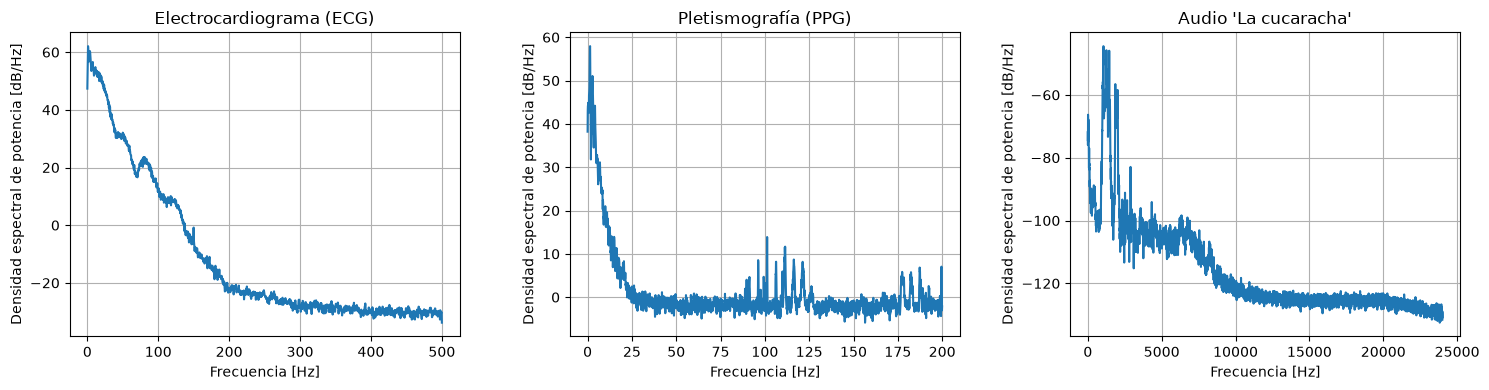


							Anchos de banda estimados

						Señal             fs              BW
						-----------------------------------------
						ECG              1000 Hz      22.67 Hz
						PPG              400 Hz       3.92 Hz
						Audio           48000 Hz     1486.67 Hz




In [60]:

#Defino la separacion entre las muestras de cada señal
delta_f_ecg = f1[1] - f1[0]
delta_f_ppg = f2[1] - f2[0]
delta_f_aud = f3[1] - f3[0]

#Hago una suma acumulativa de la potencia en cada muestra de Pxx
pot_ac_ecg = np.cumsum(Pxx_ecg) * delta_f_ecg
pot_ac_ppg = np.cumsum(Pxx_ppg) * delta_f_ppg
pot_ac_aud = np.cumsum(Pxx_aud) * delta_f_aud

#Establezco la potencia total como el valor contenido en el ultimo espacio del vector de potencia acumulada
pot_tot_ecg = pot_ac_ecg[-1]
pot_tot_ppg = pot_ac_ppg[-1]
pot_tot_aud = pot_ac_aud[-1]

#Busco el indice del vector de potencia acumulada, correspondiente a la 1era frecuencia discreta, para la cual la potencia acumulada es 95% de la total
i1 = np.where(pot_ac_ecg >= 0.95 * pot_tot_ecg)[0][0]
i2 = np.where(pot_ac_ppg >= 0.95 * pot_tot_ppg)[0][0]
i3 = np.where(pot_ac_aud >= 0.95 * pot_tot_aud)[0][0]

BW_ecg = f1[i1]
BW_ppg = f2[i2]
BW_aud = f3[i3]

"----------------------------------------------- Informo resultados --------------------------------------------"

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].plot(f1, 10*np.log10(Pxx_ecg))
axs[0].set_title("Electrocardiograma (ECG)")

axs[1].plot(f2, 10*np.log10(Pxx_ppg))
axs[1].set_title("Pletismografía (PPG)")

axs[2].plot(f3, 10*np.log10(Pxx_aud))
axs[2].set_title("Audio 'La cucaracha'")

for ax in axs.flat:
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Densidad espectral de potencia [dB/Hz]")
    ax.grid()

plt.tight_layout(w_pad=3)
plt.show()

print("\n\t\t\t\t\t      ============================================")
print("\t\t\t\t\t\t\tAnchos de banda estimados")
print("\t\t\t\t\t      ============================================")
print("\n\t\t\t\t\t\tSeñal             fs              BW")
print("\t\t\t\t\t\t-----------------------------------------")
print(f"\t\t\t\t\t\tECG              {fs_ecg} Hz      {BW_ecg:0.2f} Hz")
print(f"\t\t\t\t\t\tPPG              {fs_ppg} Hz       {BW_ppg:0.2f} Hz")
print(f"\t\t\t\t\t\tAudio           {fs_audio} Hz     {BW_aud:0.2f} Hz")
print("\n")

## <u>Análisis</u>

Lo primero que salta a la vista es que los anchos de banda de las señales electrocardiográfica y plestimografica son mucho menores al estimado para la señal de audio, lo cual tiene sentido considerando que la potencia de las primeras dos señales está distribuido en un rango de frecuencias mucho menor al de audio, y además, la PPG y el ECG contienen información asociada al ciclo cardíaco humano, por lo que es natural que la mayor parte de la potencia de las señales fisiológicas se encuentra concentrada en bajas frecuencias.

En el caso de la señal de audio, es evidente presenta un contenido espectral mucho más amplio que el de las señales fisiológicas.  A pesar de que, según el criterio de determinación de BW utilizado, el 95% de su potencia se encuentra acumulada por debajo de aprox 1486,67 Hz, se pueden distinguir múltiples picos de magnitud correspondientes a las distintas componentes frecuenciales de la grabación para frecuencias mucho mayores a la BW.